In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [8]:
print("Download the datasets from internet")
credit_data=fetch_openml(data_id=1597, as_frame=True,parser='auto')

Download the datasets from internet


In [9]:
df = credit_data.frame
print(f"data shape (Rows,Columns):{df.shape}")

data shape (Rows,Columns):(284807, 30)


In [10]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   V1      284807 non-null  float64 
 1   V2      284807 non-null  float64 
 2   V3      284807 non-null  float64 
 3   V4      284807 non-null  float64 
 4   V5      284807 non-null  float64 
 5   V6      284807 non-null  float64 
 6   V7      284807 non-null  float64 
 7   V8      284807 non-null  float64 
 8   V9      284807 non-null  float64 
 9   V10     284807 non-null  float64 
 10  V11     284807 non-null  float64 
 11  V12     284807 non-null  float64 
 12  V13     284807 non-null  float64 
 13  V14     284807 non-null  float64 
 14  V15     284807 non-null  float64 
 15  V16     284807 non-null  float64 
 16  V17     284807 non-null  float64 
 17  V18     284807 non-null  float64 
 18  V19     284807 non-null  float64 
 19  V20     284807 non-null  float64 
 20  V21     284807 non-null  f

In [12]:
df['Class']=df['Class'].astype(int)
print("Class distribution in data:\n",df['Class'].value_counts())

Class distribution in data:
 Class
0    284315
1       492
Name: count, dtype: int64


In [13]:
X=df.drop('Class',axis=1)
y=df['Class']

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
print("\n--- SMOTE...---")
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train_scaled,y_train)
print("after SMOT size of data:",pd.Series(y_train_smote).value_counts())


--- SMOTE...---
after SMOT size of data: Class
0    227451
1    227451
Name: count, dtype: int64


In [18]:
real_model_names=[]
real_accuracy_scores=[]
real_recall_scores=[]

In [19]:
ml_models={
    'Random Forest':RandomForestClassifier(n_estimators=10,random_state=42,n_jobs=-1),
    'Logistic Regression':LogisticRegression(max_iter=500,random_state=42),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'SVM':LinearSVC(random_state=42,dual=False,max_iter=2000),
    'Naive Bayes':GaussianNB()
}

In [20]:
print("\n---3. Training of machine learning models..---")
for name,model in ml_models.items():
    print(f"Training:{name}...")
    model.fit(X_train_smote,y_train_smote)
    y_pred=model.predict(X_test_scaled)
    real_model_names.append(name)
    real_accuracy_scores.append(name)
    real_accuracy_scores.append(accuracy_score(y_test,y_pred)*100)
    real_recall_scores.append(recall_score(y_test,y_pred)*100)


---3. Training of machine learning models..---
Training:Random Forest...
Training:Logistic Regression...
Training:Decision Tree...
Training:SVM...
Training:Naive Bayes...


In [22]:
print("\n---4.(Neural Networ) Training...---")
ann_real=Sequential([
    Dense(32,activation='relu',input_shape=(X_train_smote.shape[1],)),
    Dropout(0.2),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])
ann_real.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
ann_real.fit(X_train_smote,y_train_smote,epochs=5,batch_size=128, verbose=0)
ann_prob=ann_real.predict(X_test_scaled).flatten()
y_pred_ann=np.where(ann_prob>0.5,1,0)
real_model_names.append('Neural Network')
real_model_names.append(accuracy_score(y_test,y_pred_ann)*100)
real_recall_scores.append(recall_score(y_test,y_pred_ann)*100)
print("\n--- models graph...---")


---4.(Neural Networ) Training...---


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

--- models graph...---


In [24]:
df_real_compare=pd.DataFrame({
    'Model':real_model_names*2,
    'Percentage(%)':real_accuracy_scores+real_recall_scores,
    'Metric':['Accuracy']*len(real_model_names)+['Recall (Fraud Rate)']*len(real_model_names)})
plt.figure(figsize=(14,7))
ax=sns.barplot(data=df_real_compare,x='Model',y='Percentage(%)',hue='Metric',palette='Set2')
for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x()+p.get_width()/2.,p.get_height()),
                    ha='center',va='center',
                    xytext=(0,8),
                    textcoords='offset points',
                    fontsize=10,fontweight='bold')
plt.title('Final performance',fontsize=16,fontweight='bold')
plt.xlabel('ML and DL Algo',fontsize=12)
plt.ylabel('percentage(%)',fontsize=12)
plt.ylim(0,115)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

In [25]:
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
for name, model in ml_models.items():
    print("="*60)
    print(f" Algorithms:{name}".center(60,"="))
    print("="*60)
    print(f"\n--- [1] {name} (without smote)---")
    model.fit(X_train_scaled,y_train)
    y_pred_no_smote=model.predict(X_test_scaled)
    print(classification_report(y_test,y_pred_no_smote))
    print(f"---[2]{name}(with smote)---")
    model.fit(X_train_smote,y_train_smote)
    y_pred_with_smote=model.predict(X_test_scaled)
    print(classification_report(y_test,y_pred_with_smote))

================= Algorithms:Random Forest==================

--- [1] Random Forest (without smote)---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

---[2]Random Forest(with smote)---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

============== Algorithms:Logistic Regression===============

--- [1] Logistic Regression (without smote)---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00 

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
ml_models={
    'Random Forest':RandomForestClassifier(n_estimators=10,random_state=42,n_jobs=-1),
    'Logistic Regression':LogisticRegression(max_iter=500,random_state=42),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'SVM':LinearSVC(random_state=42,dual=False,max_iter=2000),
    'Naive Bayes':GaussianNB()
}
    

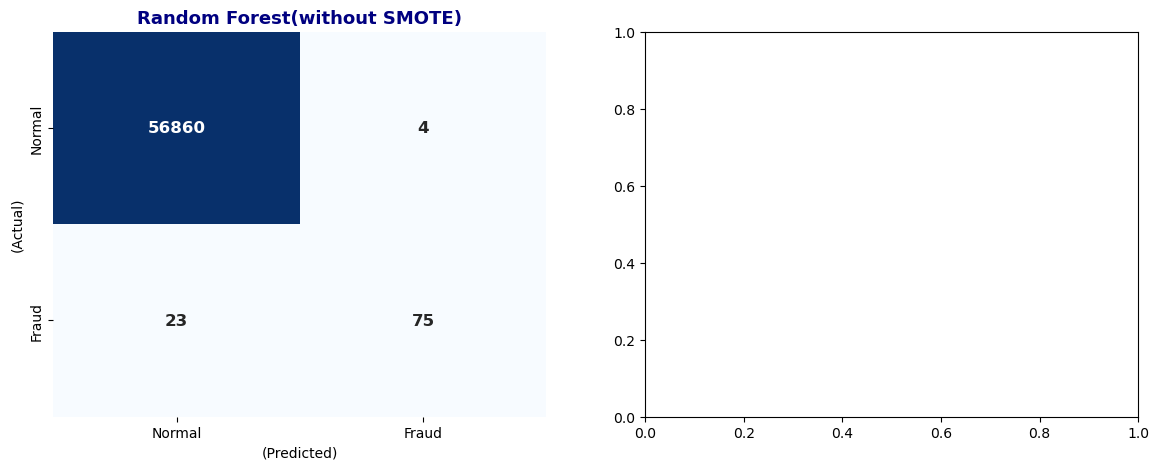

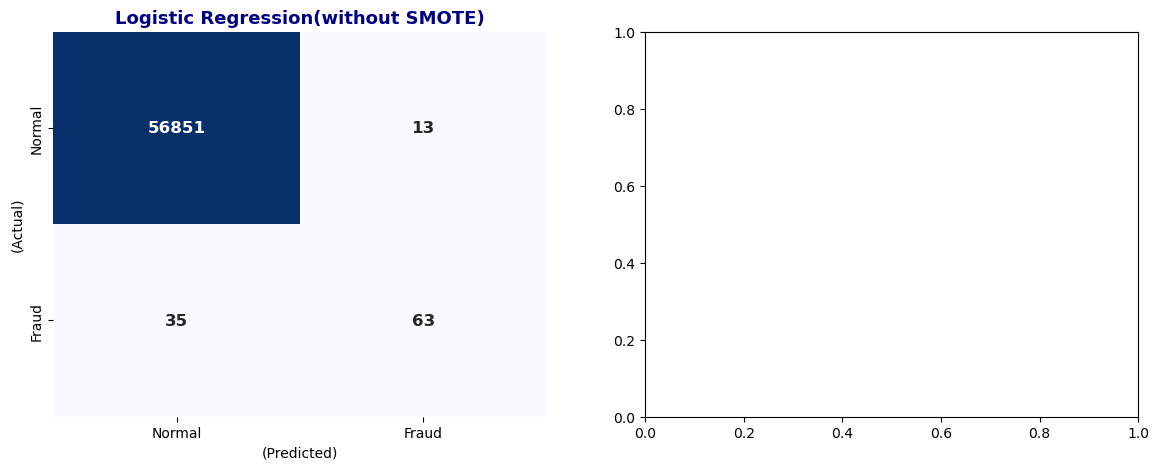

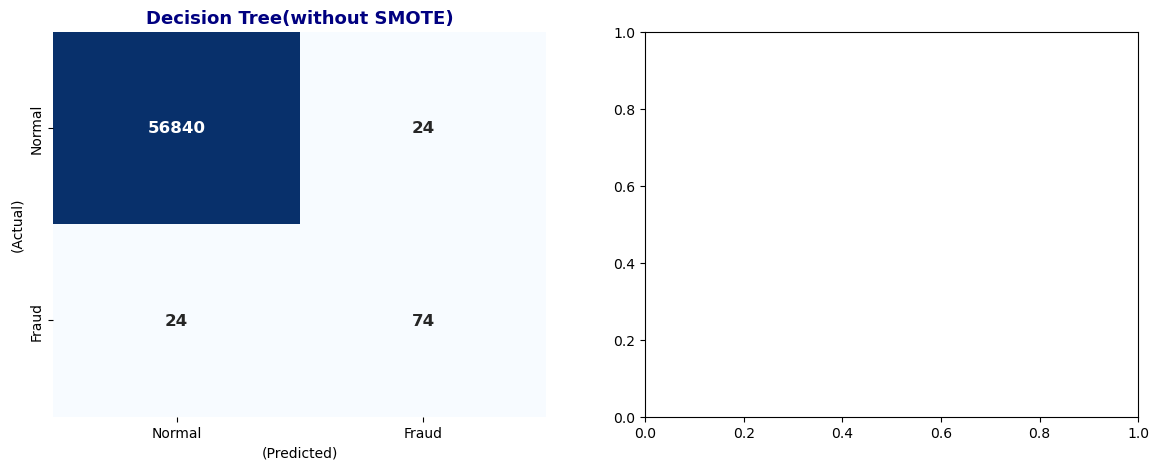

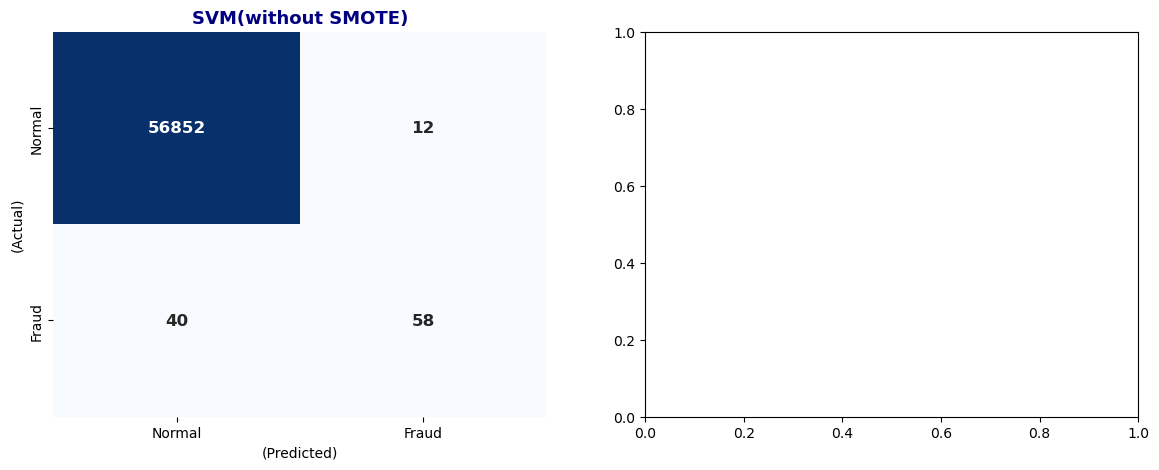

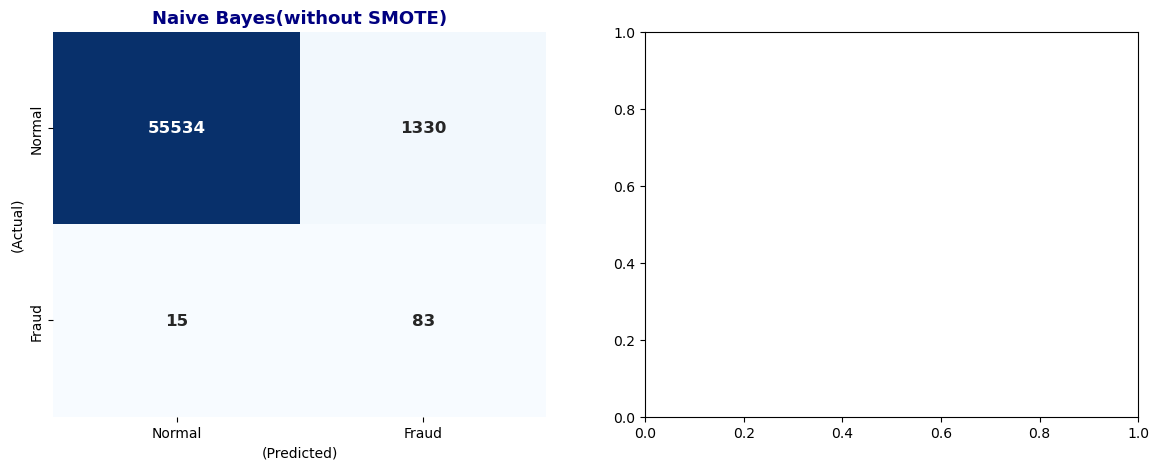

In [27]:
for name,model in ml_models.items():
    model.fit(X_train_scaled,y_train)
    y_pred_no_smote=model.predict(X_test_scaled)
    cm_no_smote=confusion_matrix(y_test,y_pred_no_smote)
    model.fit(X_train_smote,y_train_smote)
    y_pred_with_smote=model.predict(X_test_scaled)
    cm_with_smote=confusion_matrix(y_test,y_pred_with_smote)
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    sns.heatmap(cm_no_smote,annot=True,fmt='d',cmap='Blues',cbar=False,ax=axes[0],
                xticklabels=['Normal','Fraud'],yticklabels=['Normal','Fraud'],
                annot_kws={"size":12,"weight":"bold"})
    axes[0].set_title(f'{name}(without SMOTE)', fontsize=13,fontweight='bold',color='navy')
    axes[0].set_xlabel('(Predicted)')
    axes[0].set_ylabel('(Actual)')

In [28]:
sns.heatmap(cm_with_smote,annot=True,fmt='d',cmap='Greens',cbar=False,ax=axes[1],
            xticklabels=['Normal','Fraud'],yticklabels=['Normal','Fraud'],
            annot_kws={"size":12,"weight":"bold"})
axes[0].set_title(f'{name}(with SMOTE)', fontsize=13,fontweight='bold',color='darkgreen')
axes[0].set_xlabel('(Predicted)')
axes[0].set_ylabel('(Actual)')
plt.suptitle(f'==Confusion Matrix:{name}==',fontsize=15,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>